In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pipeline.load_data import load_data

sns.set_style("whitegrid")

In [4]:
df = load_data()

print(df.shape)
df.head()

(4850, 8)


,Artist,Title,Year,Sales,Streams,Downloads,Radio Plays,Rating
0,Bill Haley & his Comets,Rock Around the Clock,1955,36.503,19.961,7.458,5.663,0.760
1,Celine Dion,My Heart Will Go On,1998,35.405,12.636,8.944,23.701,3.610
2,Sinead O'Connor,Nothing Compares 2 U,1990,35.135,14.582,10.242,23.747,2.733
3,The Beatles,Hey Jude,1968,34.442,25.545,16.390,16.541,1.510
4,Bryan Adams,(Everything I Do) I Do it For You,1991,34.367,16.523,12.368,23.194,3.121


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4850 entries, 0 to 4849
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Artist       4850 non-null   str    
 1   Title        4850 non-null   str    
 2   Year         4850 non-null   int64  
 3   Sales        4850 non-null   float64
 4   Streams      4850 non-null   float64
 5   Downloads    4850 non-null   float64
 6   Radio Plays  4850 non-null   float64
 7   Rating       4850 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 441.4 KB


,Year,Sales,Streams,Downloads,Radio Plays,Rating
count,4850.000000,4850.000000,4850.000000,4850.000000,4850.000000,4850.000000
mean,1979.861443,8.154870,4.628823,2.970114,3.985120,0.481876
std,19.759676,4.555715,3.273776,2.668744,4.354419,0.624719
min,1901.000000,4.149000,0.000000,0.000000,0.000000,0.000000
25%,1967.000000,5.069250,2.351250,1.039500,0.600000,0.000000
50%,1981.000000,6.438000,4.200000,2.200000,2.570000,0.512000
75%,1996.000000,9.784000,6.307000,4.183750,5.884000,0.571000
max,2014.000000,36.503000,25.545000,19.780000,24.393000,4.460000


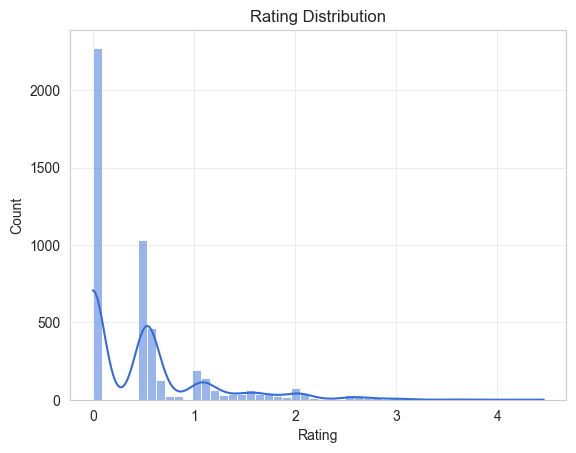

In [6]:
plt.figure()
sns.histplot(df["Rating"], bins=50, kde=True)
plt.title("Rating Distribution")
plt.show()

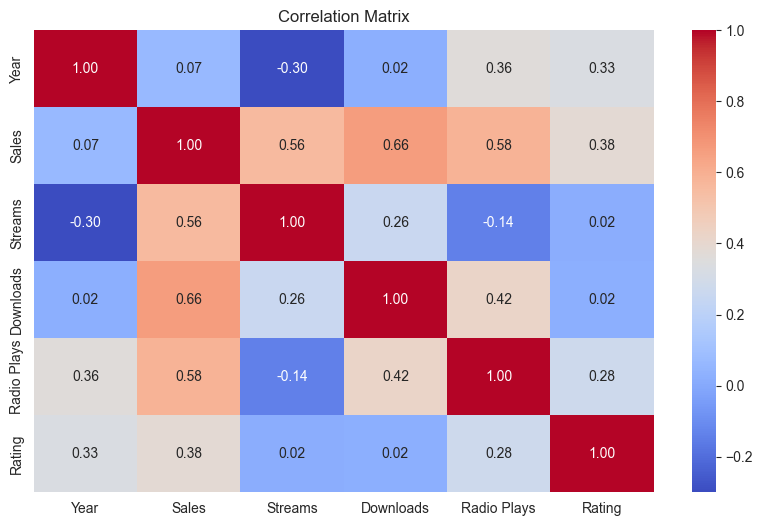

In [7]:
plt.figure(figsize=(10, 6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")

plt.show()

In [8]:
corr_target = corr["Rating"].sort_values(ascending=False)

print(corr_target)

Rating         1.000000
Sales          0.381095
Year           0.333893
Radio Plays    0.276290
Downloads      0.022912
Streams        0.019072
Name: Rating, dtype: float64


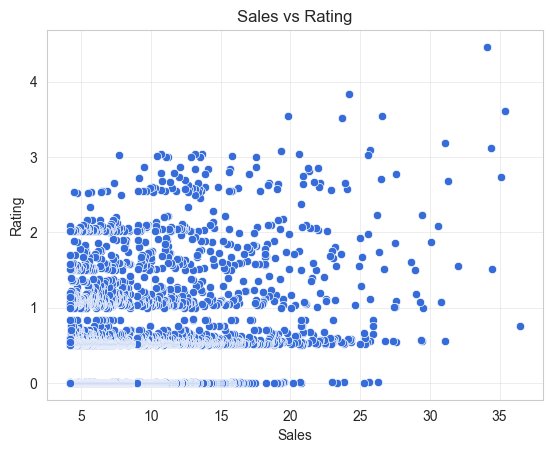

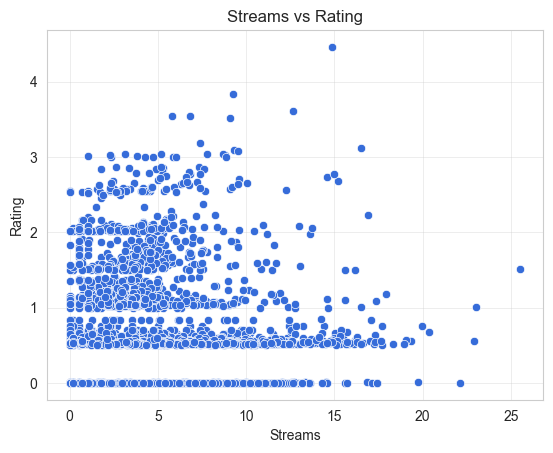

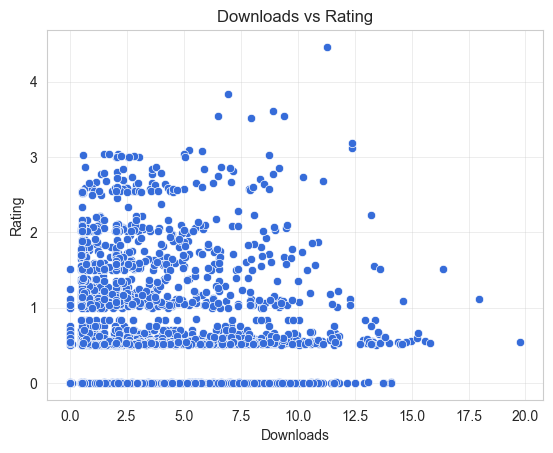

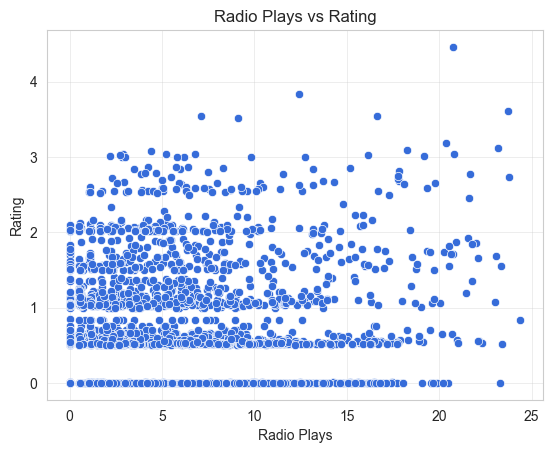

In [9]:
features = ["Sales", "Streams", "Downloads", "Radio Plays"]

for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df["Rating"])
    plt.title(f"{col} vs Rating")
    plt.show()

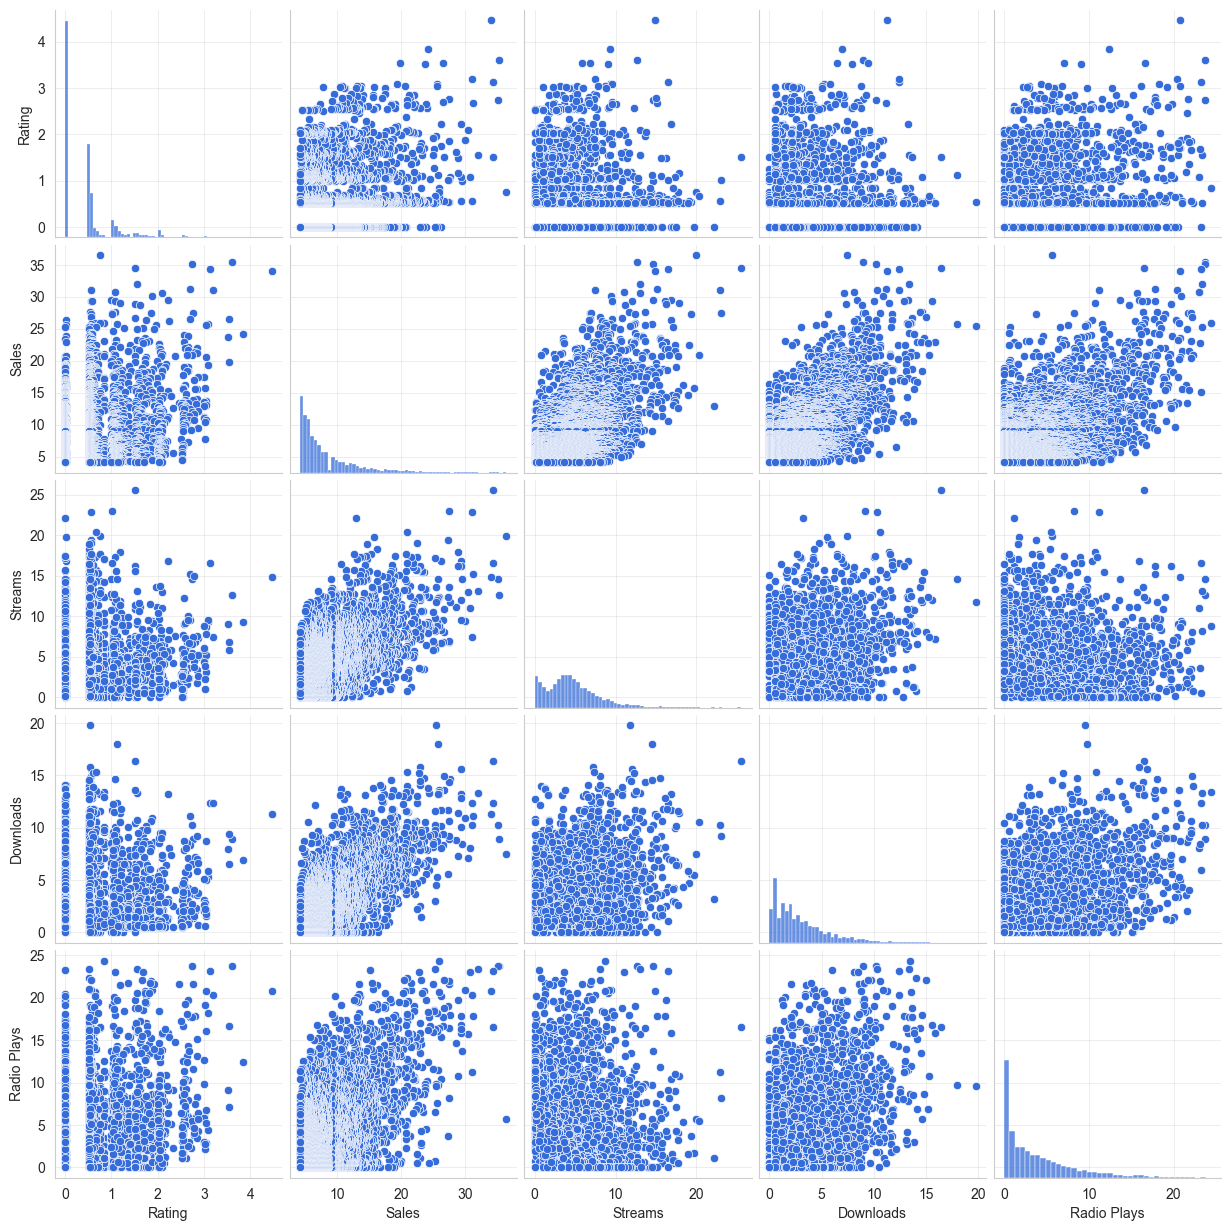

In [10]:
sns.pairplot(df[["Rating", "Sales", "Streams", "Downloads", "Radio Plays"]])
plt.show()

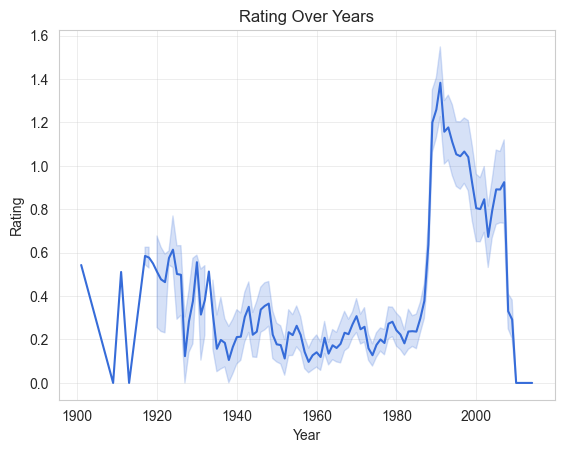

In [11]:
plt.figure()
sns.lineplot(x="Year", y="Rating", data=df)
plt.title("Rating Over Years")
plt.show()

In [12]:
top_artists = df.groupby("Artist")["Rating"].mean().sort_values(ascending=False).head(10)

print(top_artists)

Artist
Los Del Rio              3.093
Daniel Powter            3.000
Diana King               3.000
The Cardigans            2.867
Stevie B                 2.864
Snow                     2.813
P Diddy & Faith Evans    2.771
Sinead O'Connor          2.733
Brandy & Monica          2.597
The New Radicals         2.556
Name: Rating, dtype: float64
